# 🔬 ML Results Database Inspector
Sandbox for exploring experiments, metrics, and confusion matrices stored in the SQLite results DB.

> **Setup:** Set `DB_PATH` in the next cell to point at your `.db` file.

---
## 0 · Configuration

In [27]:
from pathlib import Path
import sys
import os

# Automatically find repo root by looking for .git
ROOT = Path.cwd()
while not (ROOT / ".git").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

os.chdir(ROOT)

print(f"Current root: {ROOT}")

Current root: c:\Users\rjbel\Python\Notebooks\Mapua\Thesis


In [28]:
from src.modules.machine_learning.utils.io.analysis import ResultsAnalyzer


# ── Create analyzer (replaces manual SessionStore + repo wiring) ──────────────
ra = ResultsAnalyzer("data/training_results/")

session_name = ra.current_session
DB_PATH      = ra.repo.db_path   

---
## 1 · Imports & DB connection

In [29]:
import sqlite3, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row          # column access by name
print(f"✓ Connected to {DB_PATH}")

✓ Connected to data/training_results/2026_05_09_02\results.db


---
## 2 · Schema snapshot
Lists every table and its columns.

In [30]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
print("Tables found:", tables["name"].tolist())

for tbl in tables["name"]:
    cols = pd.read_sql(f"PRAGMA table_info('{tbl}')", conn)
    print(f"\n{'─'*60}")
    print(f"  {tbl}")
    print(f"{'─'*60}")
    display(cols[["cid", "name", "type", "notnull", "dflt_value", "pk"]])

Tables found: ['cache_registry', 'charts', 'class_mappings', 'experiments', 'features', 'metadata', 'metrics', 'schema_version', 'sqlite_sequence', 'survival_results']

────────────────────────────────────────────────────────────
  cache_registry
────────────────────────────────────────────────────────────


,cid,name,type,notnull,dflt_value,pk
0,0,cache_key,TEXT,0,None,1
1,1,cache_type,TEXT,1,None,0
2,2,parameters_hash,TEXT,1,None,0
3,3,file_path,TEXT,1,None,0
4,4,created_at,TEXT,0,datetime('now'),0
5,5,metadata,TEXT,0,None,0



────────────────────────────────────────────────────────────
  charts
────────────────────────────────────────────────────────────


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,experiment_id,INTEGER,1,None,0
2,2,phase,TEXT,1,None,0
3,3,chart_type,TEXT,1,None,0
4,4,data,TEXT,0,None,0



────────────────────────────────────────────────────────────
  class_mappings
────────────────────────────────────────────────────────────


...

,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,version,INTEGER,1,None,0



────────────────────────────────────────────────────────────
  sqlite_sequence
────────────────────────────────────────────────────────────


,cid,name,type,notnull,dflt_value,pk
0,0,name,,0,None,0
1,1,seq,,0,None,0



────────────────────────────────────────────────────────────
  survival_results
────────────────────────────────────────────────────────────


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,data,TEXT,0,None,0


---
## 3 · Row counts per table

In [31]:
counts = {}
for tbl in tables["name"]:
    n = conn.execute(f"SELECT COUNT(*) FROM '{tbl}'").fetchone()[0]
    counts[tbl] = n

display(pd.DataFrame.from_dict(counts, orient="index", columns=["row_count"]))

,row_count
cache_registry,0
charts,6552
class_mappings,1
experiments,1092
features,2184
metadata,1
metrics,2184
schema_version,1
sqlite_sequence,4
survival_results,1


---
## 4 · Experiments table

In [32]:
experiments = pd.read_sql("SELECT * FROM experiments ORDER BY id", conn)
print(f"{len(experiments)} experiments")
display(experiments)

1092 experiments


,id,model,balance_strategy,undersample_threshold,parameters,param_hash,cache_key,created_at
0,1,gaussian_naive_bayes,none,NaN,"""[('var_smoothing', 0.01)]""",b8072f,db6d9835dde8822edc5883819fb47a7b,2026-05-09 13:57:42
1,2,gaussian_naive_bayes,none,NaN,"""[('var_smoothing', 0.001)]""",d58760,db6d9835dde8822edc5883819fb47a7b,2026-05-09 13:57:42
2,3,gaussian_naive_bayes,none,NaN,"""[('var_smoothing', 0.0001)]""",f0a01d,db6d9835dde8822edc5883819fb47a7b,2026-05-09 13:57:42
3,4,gaussian_naive_bayes,none,NaN,"""[('var_smoothing', 1e-05)]""",4cda36,db6d9835dde8822edc5883819fb47a7b,2026-05-09 13:57:42
4,5,gaussian_naive_bayes,none,NaN,"""[('var_smoothing', 1e-06)]""",2820ee,db6d9835dde8822edc5883819fb47a7b,2026-05-09 13:57:42
...,...,...,...,...,...,...,...,...
1087,1088,two_stage_ada_xgb,hybrid,0.9000,"""stage1={'learning_rate': 0.1, 'n_estimators':...",9c1b57,54afba68be12f953c2154a520fdd80ec,2026-05-09 13:58:12
1088,1089,two_stage_ada_xgb,hybrid,0.9000,"""stage1={'learning_rate': 0.1, 'n_estimators':...",fd0545,54afba68be12f953c2154a520fdd80ec,2026-05-09 13:58:12
1089,1090,two_stage_ada_xgb,hybrid,0.9000,"""stage1={'learning_rate': 0.1, 'n_estimators':...",2ee484,54afba68be12f953c2154a520fdd80ec,2026-05-09 13:58:12
1090,1091,two_stage_ada_xgb,hybrid,0.9000,"""stage1={'learning_rate': 0.1, 'n_estimators':...",c0790c,54afba68be12f953c2154a520fdd80ec,2026-05-09 13:58:12


---
## 5 · Metrics — full leaderboard
Joins experiments ↔ metrics and shows every phase.

In [33]:
metrics_df = pd.read_sql("""
    SELECT
        e.id              AS experiment_id,
        e.model,
        e.balance_strategy,
        e.undersample_threshold,
        m.phase,
        m.accuracy,
        m.precision_macro,
        m.recall_macro,
        m.f1_macro,
        m.roc_auc_macro
    FROM experiments e
    JOIN metrics m ON m.experiment_id = e.id
    ORDER BY m.phase DESC, m.f1_macro DESC
""", conn)

print(f"{len(metrics_df)} metric rows")
display(metrics_df)

2184 metric rows


,experiment_id,model,balance_strategy,undersample_threshold,phase,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro
0,814,two_stage_xgb_ada,borderline_smote,NaN,enhanced,0.7503,0.6066,0.6055,0.6003,0.8819
1,816,two_stage_xgb_ada,borderline_smote,NaN,enhanced,0.7462,0.6043,0.6012,0.5976,0.8800
2,811,two_stage_xgb_ada,borderline_smote,NaN,enhanced,0.7492,0.6064,0.5928,0.5948,0.8801
3,812,two_stage_xgb_ada,borderline_smote,NaN,enhanced,0.7406,0.6011,0.5995,0.5946,0.8788
4,817,two_stage_xgb_ada,borderline_smote,NaN,enhanced,0.7467,0.6075,0.5931,0.5945,0.8835
...,...,...,...,...,...,...,...,...,...,...
2179,277,ordinal_ada_boost,borderline_smote,NaN,baseline,0.5432,0.2349,0.4517,0.2920,0.7997
2180,602,ordinal_ada_boost,hybrid,0.9000,baseline,0.5473,0.2310,0.4387,0.2908,0.7918
2181,170,ada_boost,borderline_smote,NaN,baseline,0.4888,0.2562,0.4431,0.2726,0.7649
2182,198,ada_boost,borderline_smote,NaN,baseline,0.4888,0.2562,0.4431,0.2726,0.7649


---
## 6 · Best result per model (enhanced phase)

In [34]:
best_per_model = pd.read_sql("""
    SELECT
        e.id              AS experiment_id,
        e.model,
        e.balance_strategy,
        m.accuracy,
        m.precision_macro,
        m.recall_macro,
        m.f1_macro,
        m.roc_auc_macro
    FROM experiments e
    JOIN metrics m ON m.experiment_id = e.id
    WHERE m.phase = 'enhanced'
    GROUP BY e.model
    HAVING m.f1_macro = MAX(m.f1_macro)
    ORDER BY m.f1_macro DESC
""", conn)

print(f"Best per model ({len(best_per_model)} rows):")
display(best_per_model)

Best per model (15 rows):


,experiment_id,model,balance_strategy,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro
0,814,two_stage_xgb_ada,borderline_smote,0.7503,0.6066,0.6055,0.6003,0.8819
1,287,two_stage_rf_ada,borderline_smote,0.7330,0.5953,0.5910,0.5880,0.8716
2,154,two_stage_rf_rf,smote,0.7065,0.5583,0.5829,0.5646,0.8660
3,467,ordinal_ada_boost,hybrid,0.6974,0.5606,0.5768,0.5621,0.8205
4,736,two_stage_xgb_rf,smote,0.7070,0.5542,0.5807,0.5606,0.8669
5,895,xgboost,hybrid,0.6897,0.5621,0.5819,0.5589,0.8607
6,85,ada_boost,smote,0.7213,0.5959,0.5453,0.5582,0.8137
7,385,random_forest,hybrid,0.7085,0.5488,0.5763,0.5581,0.8566
8,723,two_stage_xgb_xgb,smote,0.7075,0.5459,0.5714,0.5521,0.8700
9,318,ordinal_random_forest,smote_tomek,0.6826,0.5522,0.5682,0.5498,0.8493


---
## 7 · Charts table — keys inventory
Shows what chart types exist and their JSON top-level keys, without loading the full blobs.

In [35]:
charts_meta = pd.read_sql("""
    SELECT
        c.id,
        c.experiment_id,
        e.model,
        e.balance_strategy,
        c.phase,
        c.chart_type,
        LENGTH(c.data)  AS data_bytes
    FROM charts c
    JOIN experiments e ON e.id = c.experiment_id
    ORDER BY c.experiment_id, c.phase, c.chart_type
""", conn)

print(f"{len(charts_meta)} chart rows")
display(charts_meta)

6552 chart rows


,id,experiment_id,model,balance_strategy,phase,chart_type,data_bytes
0,1,1,gaussian_naive_bayes,none,baseline,confusion_matrix,70
1,3,1,gaussian_naive_bayes,none,baseline,pr_curve,314230
2,2,1,gaussian_naive_bayes,none,baseline,roc_curve,75958
3,4,1,gaussian_naive_bayes,none,enhanced,confusion_matrix,70
4,6,1,gaussian_naive_bayes,none,enhanced,pr_curve,313796
...,...,...,...,...,...,...,...
6547,6549,1092,two_stage_ada_xgb,hybrid,baseline,pr_curve,286385
6548,6548,1092,two_stage_ada_xgb,hybrid,baseline,roc_curve,75487
6549,6550,1092,two_stage_ada_xgb,hybrid,enhanced,confusion_matrix,75
6550,6552,1092,two_stage_ada_xgb,hybrid,enhanced,pr_curve,284492


In [36]:
# Peek at the JSON keys for each distinct chart_type
distinct_types = charts_meta["chart_type"].unique()
for ct in distinct_types:
    sample_id = charts_meta.loc[charts_meta["chart_type"] == ct, "id"].iloc[0]
    raw = conn.execute("SELECT data FROM charts WHERE id = ?", (int(sample_id),)).fetchone()[0]
    parsed = json.loads(raw)
    if isinstance(parsed, dict):
        print(f"chart_type={ct!r:25s}  → dict keys: {list(parsed.keys())}")
    elif isinstance(parsed, list):
        print(f"chart_type={ct!r:25s}  → bare list, len={len(parsed)}, "
              f"first-row type={type(parsed[0]).__name__}")
    else:
        print(f"chart_type={ct!r:25s}  → unexpected type: {type(parsed)}")

chart_type='confusion_matrix'         → bare list, len=4, first-row type=list
chart_type='pr_curve'                 → dict keys: ['0', '1', '2', '3']
chart_type='roc_curve'                → dict keys: ['0', '1', '2', '3']


---
## 8 · Confusion matrix — raw data viewer
Load the CM for any single experiment by ID.

In [37]:
def load_confusion_matrix(experiment_id: int, phase: str = "enhanced") -> np.ndarray | None:
    """Return the confusion matrix as a numpy array, or None if not found."""
    row = conn.execute("""
        SELECT data FROM charts
        WHERE experiment_id = ? AND phase = ? AND chart_type = 'confusion_matrix'
    """, (experiment_id, phase)).fetchone()

    if row is None:
        print(f"No confusion_matrix for experiment_id={experiment_id}, phase={phase!r}")
        return None

    cm_data = json.loads(row[0])
    if isinstance(cm_data, list):
        matrix = cm_data
    elif isinstance(cm_data, dict):
        matrix = cm_data.get("matrix") or cm_data.get("data") or cm_data.get("values")
        if matrix is None:
            print(f"Cannot find matrix key. Available keys: {list(cm_data.keys())}")
            return None
    else:
        print(f"Unexpected CM type: {type(cm_data)}")
        return None

    return np.array(matrix, dtype=float)


# ── Quick demo: load CM for each best-per-model experiment ───────────────────
for _, row in best_per_model.iterrows():
    exp_id = int(row["experiment_id"])
    cm = load_confusion_matrix(exp_id)
    if cm is not None:
        print(f"\nexperiment_id={exp_id}  model={row['model']}  "
              f"shape={cm.shape}  sum={cm.sum():.0f}")
        print(cm)


experiment_id=814  model=two_stage_xgb_ada  shape=(4, 4)  sum=1966
[[874.  65.  37.  19.]
 [ 52. 467.  90.  38.]
 [  8.  71.  56.  11.]
 [  4.  42.  54.  78.]]

experiment_id=287  model=two_stage_rf_ada  shape=(4, 4)  sum=1966
[[864.  77.  35.  19.]
 [ 80. 445.  86.  36.]
 [ 14.  67.  54.  11.]
 [  6.  40.  54.  78.]]

experiment_id=154  model=two_stage_rf_rf  shape=(4, 4)  sum=1966
[[843.  75.  42.  35.]
 [ 60. 402. 115.  70.]
 [  7.  74.  44.  21.]
 [  4.  37.  37. 100.]]

experiment_id=467  model=ordinal_ada_boost  shape=(4, 4)  sum=1966
[[823.  83.  62.  27.]
 [ 76. 408. 115.  48.]
 [  8.  58.  51.  29.]
 [ 15.  37.  37.  89.]]

experiment_id=736  model=two_stage_xgb_rf  shape=(4, 4)  sum=1966
[[847.  69.  40.  39.]
 [ 47. 401. 118.  81.]
 [  8.  73.  44.  21.]
 [  2.  43.  35.  98.]]

experiment_id=895  model=xgboost  shape=(4, 4)  sum=1966
[[833.  61.  74.  27.]
 [ 48. 370. 159.  70.]
 [  6.  64.  48.  28.]
 [  3.  28.  42. 105.]]

experiment_id=85  model=ada_boost  shape=(4, 4)

---
## 9 · Class mappings

In [38]:
cm_row = conn.execute("SELECT data FROM class_mappings LIMIT 1").fetchone()
if cm_row:
    class_mappings = json.loads(cm_row[0])
    print("class_mappings:", class_mappings)
    class_labels = sorted(class_mappings.keys(), key=lambda k: class_mappings[k])
    print("Ordered labels:", class_labels)
else:
    print("No class_mappings found — using generic labels")
    # Infer label count from first CM
    first_exp = int(best_per_model["experiment_id"].iloc[0])
    cm = load_confusion_matrix(first_exp)
    n = cm.shape[0] if cm is not None else 2
    class_labels = [f"Class {i}" for i in range(n)]
    class_mappings = {lbl: i for i, lbl in enumerate(class_labels)}

class_mappings: {'on_time': 0, '30_days': 1, '60_days': 2, '90_days': 3}
Ordered labels: ['on_time', '30_days', '60_days', '90_days']


---
## 10 · Confusion matrix visualizer
Plot normalised confusion matrices for the top-N models.

In [39]:
# ── Colour palette (edit to match your theme) ────────────────────────────────
BG_COLOR     = "#F8F9FB"
TEXT_DARK    = "#1A1D23"
TEXT_MID     = "#5A6072"
SURV_COLOR   = "#2A7AE4"
NOSURV_COLOR = "#E05B4B"
NOSURV_LIGHT = "#F5B8B1"
GRID_COLOR   = "#D4D8E2"

CM_CMAP = LinearSegmentedColormap.from_list(
    "cm_custom",
    [BG_COLOR, "#B8D0F5", SURV_COLOR],
    N=256,
)


def draw_metric_badge(ax, label_text, color, y=1.14):
    bbox_props = dict(
        boxstyle="round,pad=0.3,rounding_size=0.5",
        facecolor=color, edgecolor=color,
        alpha=0.12, linewidth=0.8,
    )
    ax.text(
        1.0, y, f" {label_text} ",
        transform=ax.transAxes, ha="right", va="center",
        fontsize=8.5, fontweight="bold", color=color,
        bbox=bbox_props, clip_on=False, zorder=10,
    )


def plot_cm(matrix_raw, title, ax, class_labels, f1_score=None):
    cm      = np.array(matrix_raw, dtype=float)
    n       = cm.shape[0]
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

    ax.imshow(cm_norm, cmap=CM_CMAP, vmin=0, vmax=1, aspect="equal")

    for edge in range(n + 1):
        ax.axhline(edge - 0.5, color="white", linewidth=1.8, zorder=2)
        ax.axvline(edge - 0.5, color="white", linewidth=1.8, zorder=2)

    for i in range(n):
        for j in range(n):
            pct   = cm_norm[i, j]
            count = int(cm[i, j])
            color = "white" if pct > 0.50 else TEXT_DARK
            ax.text(j, i - 0.12, f"{pct:.2f}",
                    ha="center", va="center", color=color,
                    fontsize=8.5, fontweight="bold", zorder=3)
            ax.text(j, i + 0.22, f"({count})",
                    ha="center", va="center", color=color,
                    fontsize=7, alpha=0.75, zorder=3)

    clean_labels = [re.sub(r"\s*\(\d+\)\s*$", "", c) for c in class_labels]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(clean_labels, rotation=30, ha="right", fontsize=7.5, color=TEXT_MID)
    ax.set_yticklabels(clean_labels, fontsize=7.5, color=TEXT_MID)
    ax.tick_params(axis="both", length=0, pad=6)
    ax.set_xlabel("Predicted", fontsize=9, color=TEXT_MID, labelpad=8)
    ax.set_ylabel("Actual",    fontsize=9, color=TEXT_MID, labelpad=8)
    for spine in ax.spines.values():
        spine.set_visible(False)

    HEADER_Y = 1.10
    ax.text(0.0, HEADER_Y, title,
            transform=ax.transAxes, ha="left", va="center",
            fontsize=10.5, fontweight="bold", color=TEXT_DARK,
            clip_on=False, zorder=10)
    if f1_score is not None:
        draw_metric_badge(ax, f"F1 = {f1_score:.3f}", SURV_COLOR, y=HEADER_Y)


print("Helpers defined ✓")

Helpers defined ✓


3 confusion matrices loaded


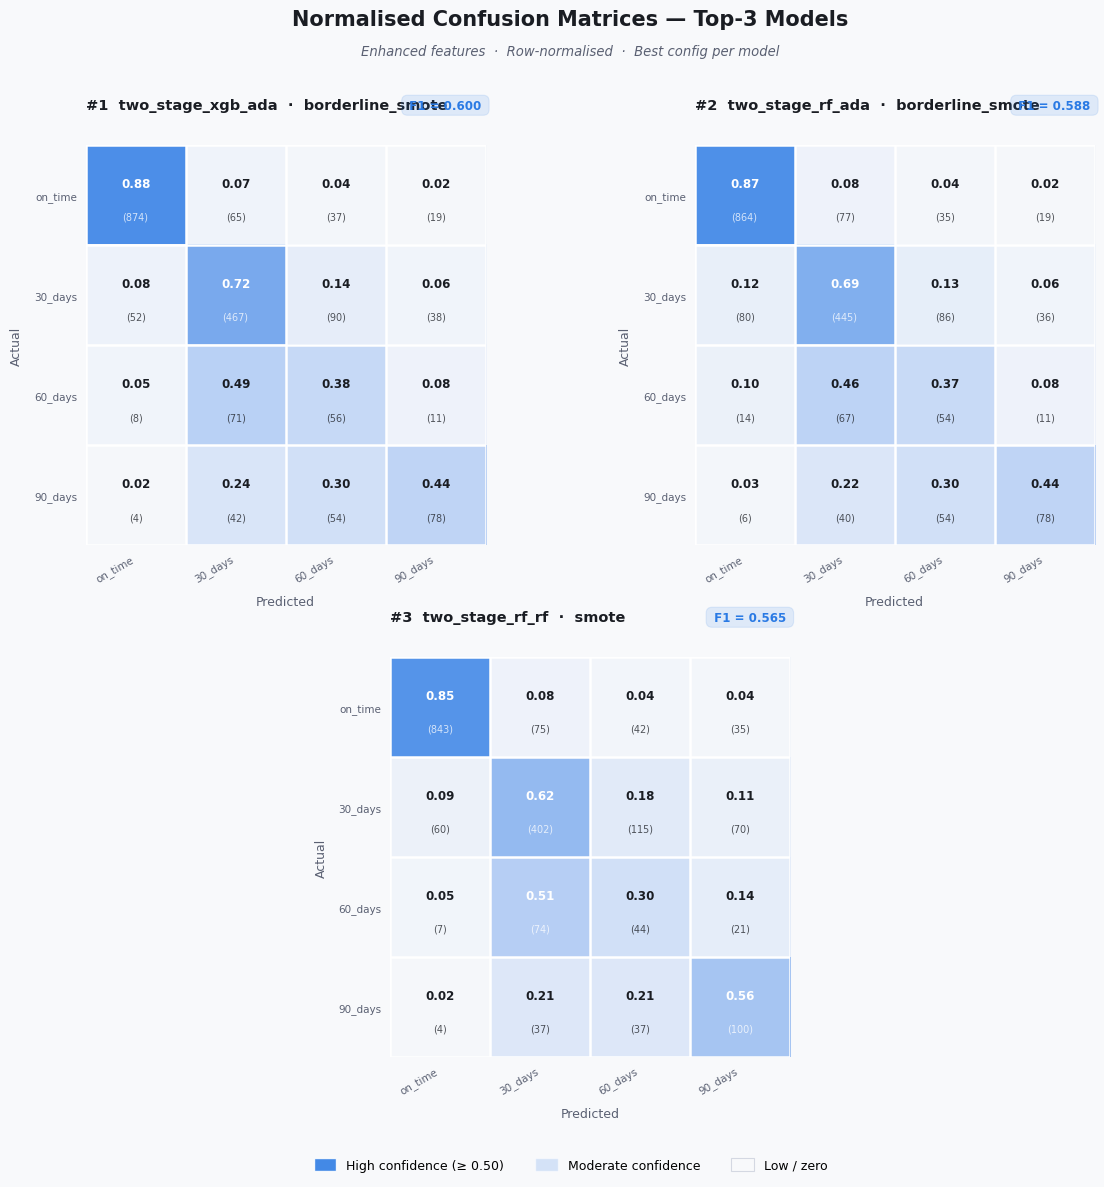

✓ Saved fig_confusion_matrices_top3.png


In [ ]:
# ── ✏️  Change TOP_N to control how many models to plot (max 3 recommended) ──
TOP_N = 3
PHASE = "enhanced"   # "baseline" or "enhanced"
# ─────────────────────────────────────────────────────────────────────────────

top_rows = best_per_model.head(TOP_N)
models   = []

for rank, (_, row) in enumerate(top_rows.iterrows(), start=1):
    exp_id = int(row["experiment_id"])
    cm     = load_confusion_matrix(exp_id, phase=PHASE)
    if cm is None:
        continue
    models.append({
        "title":  f"#{rank}  {row['model']}  ·  {row['balance_strategy']}",
        "f1":     row["f1_macro"],
        "matrix": cm,
    })

n_models = len(models)
print(f"{n_models} confusion matrices loaded")

if n_models == 0:
    print("⚠ Nothing to plot — check that chart rows exist for these experiment IDs.")
else:
    if n_models == 3:
        fig = plt.figure(figsize=(13, 12), facecolor=BG_COLOR)
        gs  = fig.add_gridspec(2, 4, hspace=0.28, wspace=0.40,
                               left=0.08, right=0.95, top=0.86, bottom=0.10)
        axes = [
            fig.add_subplot(gs[0, 0:2]),
            fig.add_subplot(gs[0, 2:4]),
            fig.add_subplot(gs[1, 1:3]),
        ]
    elif n_models == 2:
        fig  = plt.figure(figsize=(13, 7), facecolor=BG_COLOR)
        gs   = fig.add_gridspec(1, 4, wspace=0.40,
                                left=0.08, right=0.95, top=0.86, bottom=0.10)
        axes = [fig.add_subplot(gs[0, 0:2]), fig.add_subplot(gs[0, 2:4])]
    else:
        fig  = plt.figure(figsize=(7, 7), facecolor=BG_COLOR)
        axes = [fig.add_subplot(111)]

    for ax, model in zip(axes, models):
        plot_cm(model["matrix"], model["title"], ax,
                class_labels=class_labels, f1_score=model["f1"])

    fig.text(0.5, 0.96, f"Normalised Confusion Matrices — Top-{n_models} Models",
             ha="center", fontsize=15, fontweight="bold", color=TEXT_DARK)
    fig.text(0.5, 0.935,
             f"{PHASE.title()} features  ·  Row-normalised  ·  Best config per model",
             ha="center", fontsize=9.5, color=TEXT_MID, fontstyle="italic")

    legend_patches = [
        mpatches.Patch(facecolor=SURV_COLOR,   alpha=0.88, edgecolor="white",
                       label="High confidence (≥ 0.50)"),
        mpatches.Patch(facecolor="#B8D0F5",    alpha=0.55, edgecolor="white",
                       label="Moderate confidence"),
        mpatches.Patch(facecolor=BG_COLOR,     edgecolor=GRID_COLOR, linewidth=0.8,
                       label="Low / zero"),
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=3,
               fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.005),
               handlelength=1.8, handleheight=1.2, columnspacing=2.5)

    #plt.savefig("fig_confusion_matrices_top3.png",
    #            bbox_inches="tight", dpi=180, facecolor=BG_COLOR)
    plt.show()
    #print("✓ Saved fig_confusion_matrices_top3.png")

---
## 11 · Drill-down: single experiment
Inspect every chart and metric for one specific experiment.

In [41]:
# ── ✏️  Change this to any experiment_id you want to inspect ─────────────────
INSPECT_ID = 1
# ─────────────────────────────────────────────────────────────────────────────

exp = pd.read_sql("SELECT * FROM experiments WHERE id = ?", conn, params=(INSPECT_ID,))
print("=== Experiment ===")
display(exp)

mets = pd.read_sql("SELECT * FROM metrics WHERE experiment_id = ?", conn, params=(INSPECT_ID,))
print("\n=== Metrics ===")
display(mets)

chts = pd.read_sql("""
    SELECT id, phase, chart_type, LENGTH(data) AS bytes FROM charts
    WHERE experiment_id = ?
""", conn, params=(INSPECT_ID,))
print("\n=== Charts ===")
display(chts)

feats = pd.read_sql("""
    SELECT id, phase, feature_method FROM features WHERE experiment_id = ?
""", conn, params=(INSPECT_ID,))
print("\n=== Features ===")
display(feats)

=== Experiment ===


,id,model,balance_strategy,undersample_threshold,parameters,param_hash,cache_key,created_at
0,1,gaussian_naive_bayes,none,None,"""[('var_smoothing', 0.01)]""",b8072f,db6d9835dde8822edc5883819fb47a7b,2026-05-09 13:57:42



=== Metrics ===


,id,experiment_id,phase,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro
0,1,1,baseline,0.6053,0.4246,0.3827,0.3726,0.6618
1,2,1,enhanced,0.6068,0.4271,0.3862,0.3767,0.6649



=== Charts ===


,id,phase,chart_type,bytes
0,1,baseline,confusion_matrix,70
1,2,baseline,roc_curve,75958
2,3,baseline,pr_curve,314230
3,4,enhanced,confusion_matrix,70
4,5,enhanced,roc_curve,79050
5,6,enhanced,pr_curve,313796



=== Features ===


,id,phase,feature_method
0,1,baseline,GaussianNB influence score
1,2,enhanced,GaussianNB influence score


---
## 12 · Baseline vs Enhanced — side-by-side metrics

In [42]:
pivot = pd.read_sql("""
    SELECT
        e.model,
        e.balance_strategy,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.f1_macro    END) AS base_f1,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.f1_macro    END) AS enh_f1,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.roc_auc_macro END) AS base_auc,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.roc_auc_macro END) AS enh_auc
    FROM experiments e
    JOIN metrics m ON m.experiment_id = e.id
    GROUP BY e.id
    ORDER BY enh_f1 DESC
""", conn)

pivot["f1_delta"]  = pivot["enh_f1"]  - pivot["base_f1"]
pivot["auc_delta"] = pivot["enh_auc"] - pivot["base_auc"]
display(pivot)

,model,balance_strategy,base_f1,enh_f1,base_auc,enh_auc,f1_delta,auc_delta
0,two_stage_xgb_ada,borderline_smote,0.5930,0.6003,0.8763,0.8819,0.0073,0.0056
1,two_stage_xgb_ada,borderline_smote,0.5958,0.5976,0.8802,0.8800,0.0018,-0.0003
2,two_stage_xgb_ada,borderline_smote,0.5943,0.5948,0.8790,0.8801,0.0004,0.0011
3,two_stage_xgb_ada,borderline_smote,0.5960,0.5946,0.8780,0.8788,-0.0014,0.0007
4,two_stage_xgb_ada,borderline_smote,0.5983,0.5945,0.8815,0.8835,-0.0038,0.0020
...,...,...,...,...,...,...,...,...
1087,ordinal_ada_boost,smote,0.2938,0.2925,0.8092,0.8141,-0.0013,0.0050
1088,ordinal_ada_boost,borderline_smote,0.2920,0.2920,0.7997,0.8004,-0.0001,0.0007
1089,ada_boost,borderline_smote,0.2726,0.2726,0.7649,0.7649,0.0000,0.0000
1090,ada_boost,borderline_smote,0.2726,0.2726,0.7649,0.7649,0.0000,0.0000


---
## 13 · Metadata & survival results (optional blobs)

In [43]:
for blob_table in ("metadata", "survival_results"):
    row = conn.execute(f"SELECT data FROM {blob_table} LIMIT 1").fetchone()
    print(f"\n{'='*60}")
    print(f"  {blob_table}")
    print(f"{'='*60}")
    if row:
        parsed = json.loads(row[0])
        print(json.dumps(parsed, indent=2)[:2000])   # cap at 2 000 chars
    else:
        print("  (empty)")


  metadata
{
  "timestamp": "2026-05-09T21:57:42.400490",
  "num_models_trained": 8,
  "model_names": [
    "ada_boost",
    "decision_tree",
    "gaussian_naive_bayes",
    "knn",
    "random_forest",
    "xgboost",
    "ordinal",
    "two_stage"
  ],
  "num_experiments": 1092,
  "results_format": "sqlite",
  "training_start_time": "2026-05-09T19:54:34",
  "training_end_time": "2026-05-09T21:57:42",
  "training_run_time": "2h 3m 7s",
  "run_folder_path": "data/training_results\\2026_05_09_02"
}

  survival_results
{
  "best_c_index": 0.7817,
  "best_parameters": {
    "alpha": 0.05,
    "l1_ratio": 0.5
  },
  "time_points": [
    1,
    16,
    30,
    58,
    76,
    118,
    150,
    306,
    324
  ]
}


---
## 14 · Cache registry

In [44]:
try:
    cache_df = pd.read_sql("SELECT * FROM cache_registry ORDER BY created_at DESC", conn)
    print(f"{len(cache_df)} cache entries")
    display(cache_df)
except Exception as e:
    print(f"cache_registry not available: {e}")

0 cache entries


,cache_key,cache_type,parameters_hash,file_path,created_at,metadata


---
## 15 · Close connection

In [45]:
conn.close()
print("Connection closed ✓")

Connection closed ✓
